# ViT from scratch

ViTs (Vision transformers) are a purely attention based architecture developed by Google. They were originally trained and tested on Imagenet, however I have a Macbook so I will be training and testing my custom model and an adapted pretrained model, within separate files, using the test version of ImageNet-1K.
This is a reimplementation of it, however with some parameters scaled down.

https://arxiv.org/pdf/2010.11929

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

import torchvision
from torchvision import transforms
from torchvision.datasets import ImageFolder

import torchinfo
from torchinfo import summary

import matplotlib
import matplotlib.pyplot as plt

import tqdm as tqdm_version_check

from training import train , lr_lambda

print(f"Torch version : {torch.__version__}")
print(f"Torchvision version : {torchvision.__version__}")
print(f"Torchinfo version : {torchinfo.__version__}")
print(f"Matplotlib version : {matplotlib.__version__}")
print(f"TQDM version : {tqdm_version_check.__version__}")

Torch version : 2.8.0
Torchvision version : 0.24.0
Torchinfo version : 1.8.0
Matplotlib version : 3.10.8
TQDM version : 4.67.1


/Users/ammarnagri/miniconda3/envs/ViT_reprod/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Getting the data ready

First, we'll download the data and extract the class names

In [2]:
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor()
])

train_data = ImageFolder(
    root="archive/train",
    transform=transform
    )

test_data = ImageFolder(
    root="archive/test",
    transform=transform
    )

In [3]:
class_names = train_data.classes
class_to_idx = train_data.class_to_idx
idx_to_class = {idx: class_name for class_name, idx in class_to_idx.items()}

matplotlib.pyplot expects data to be in a HWC (height–width–channels) format, however pytorch provides the images in a (channels–height–width) therefore to visualise it, the data has to be manipulated

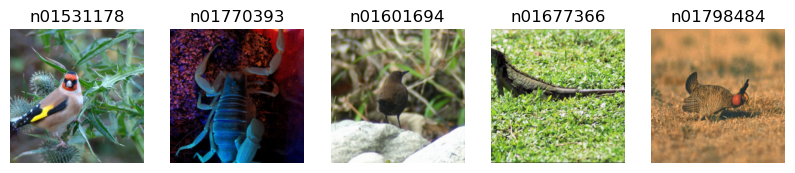

In [4]:
fig = plt.figure(figsize=(10,10))
row , col = 1,5
for i in range (1,(row * col) + 1):
    id = torch.randint(size=[1],low = 0 , high=len(train_data)).item()
    img , label = train_data[id]
    fig.add_subplot(row , col , i)
    plt.imshow(img.permute(1,2,0))
    plt.title(class_names[label])
    plt.axis(False)

In [5]:
COLOUR_CHANNELS,HEIGHT,WIDTH = train_data[0][0].shape[0],train_data[0][0].shape[1],train_data[0][0].shape[2]
COLOUR_CHANNELS,HEIGHT,WIDTH

(3, 224, 224)

Patches are small fixed sections of a split up image so transformers can relate each section to each other to learn the image better and not require reccurence. The number of patches is decided by the original image size and the patch size. The patch size in this is denoted by $P$.

In [6]:
PATCH_SIZE = 16
num_patches_per_row = int(HEIGHT/PATCH_SIZE)
num_patches_per_col = int(WIDTH/PATCH_SIZE)
num_patches = int((HEIGHT * WIDTH) / PATCH_SIZE**2)
PATCH_SIZE, num_patches_per_row,num_patches_per_col,num_patches

(16, 14, 14, 196)

The model first has to embed the image into tensors that are able to be processed. The layer which does this is called the embedding layer.
The image tensor originally has the shape $\mathbf{x} \in \mathbb{R}^{H \times W \times C}$, and it is transformed into a sequence of flattened 2D patches of shape $\mathbf{x}_p \in \mathbb{R}^{N \times (P^{2} \cdot C)}$, where $C$ is the number of colour channels and $H$ and $W$ correspond to height and width.
The resolution of each patch is $(P,P)$, where $P$ is the size of a patch. 

In [7]:
embedding_layer_input_shape = (HEIGHT, WIDTH, COLOUR_CHANNELS)
embedding_layer_output_shape = (num_patches, PATCH_SIZE**2 * COLOUR_CHANNELS)

print(f"Input shape (single 2D image): {embedding_layer_input_shape}")
print(f"Output shape (single 2D image flattened into patches): {embedding_layer_output_shape}")

Input shape (single 2D image): (224, 224, 3)
Output shape (single 2D image flattened into patches): (196, 768)


In [8]:
test_img, test_label = train_data[0]

Number of patches per row: 14        
Number of patches per column: 14        
Total patches: 196        
Patch size: 16 pixels x 16 pixels


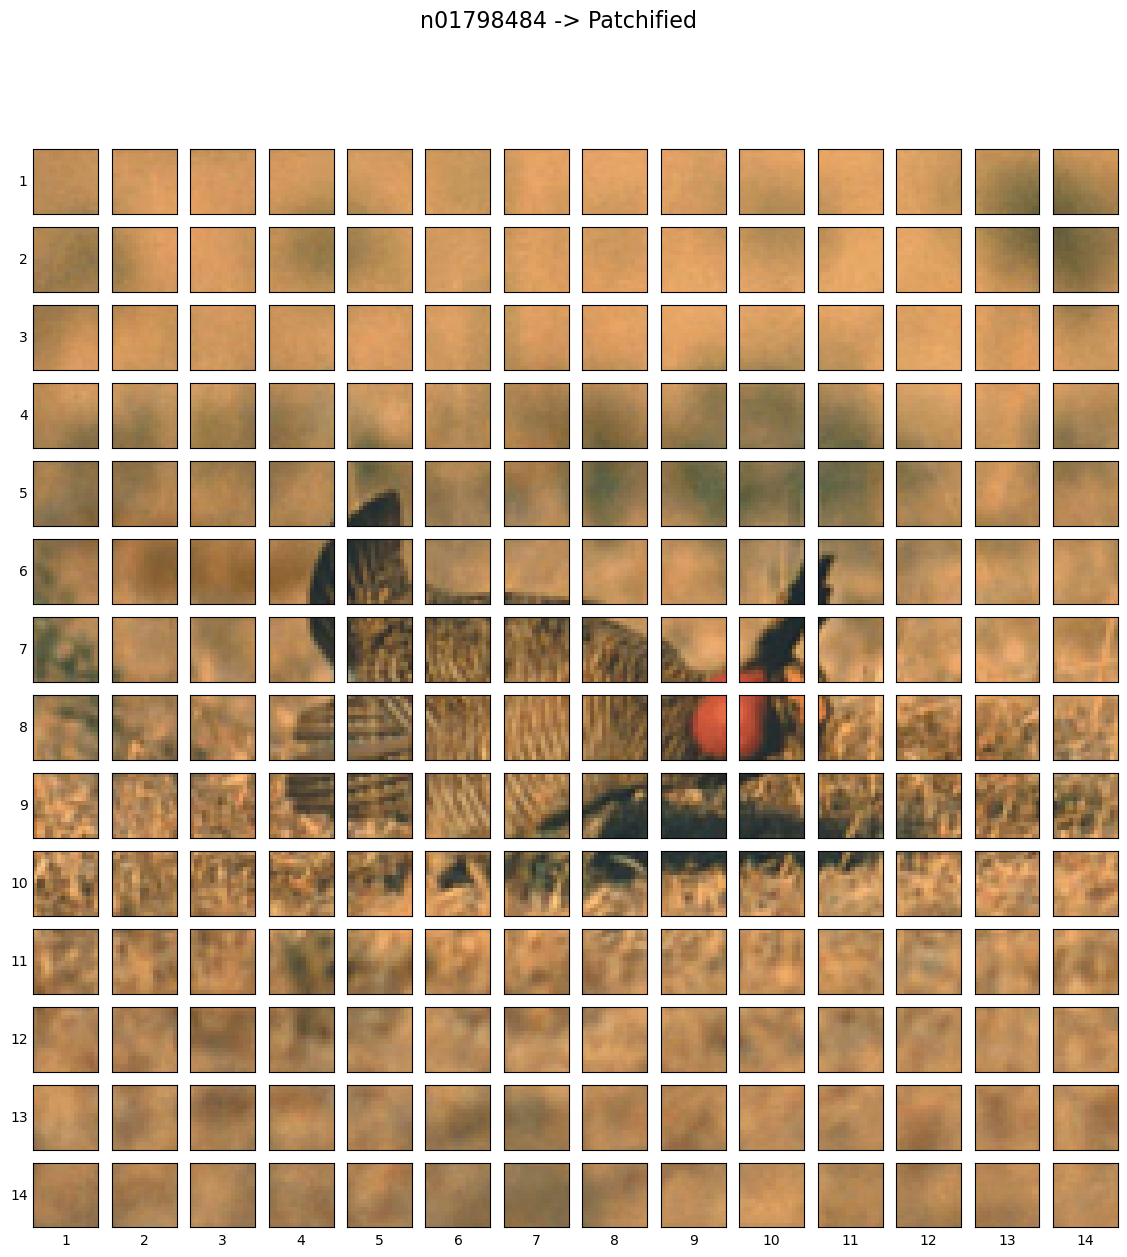

In [9]:
image_permuted = img.permute(1, 2, 0)

num_patches = HEIGHT//PATCH_SIZE

assert HEIGHT % PATCH_SIZE == 0, "Image size must be divisible by patch size"
print(f"Number of patches per row: {num_patches_per_row}\
        \nNumber of patches per column: {num_patches_per_col}\
        \nTotal patches: {num_patches*num_patches}\
        \nPatch size: {PATCH_SIZE} pixels x {PATCH_SIZE} pixels")

# Create a series of subplots
fig, axs = plt.subplots(nrows=num_patches_per_row, # need int not float
                        ncols=num_patches_per_col,
                        figsize=(num_patches, num_patches),
                        sharex=True,
                        sharey=True)

# Loop through height and width of image
for i, patch_height in enumerate(range(0, HEIGHT, PATCH_SIZE)): # iterate through height
    for j, patch_width in enumerate(range(0, WIDTH, PATCH_SIZE)): # iterate through width

        # Plot the permuted image patch (image_permuted -> (Height, Width, Color Channels))
        axs[i, j].imshow(image_permuted[patch_height:patch_height+PATCH_SIZE, # iterate through height
                                        patch_width:patch_width+PATCH_SIZE, # iterate through width
                                        :]) # get all color channels

        # Set up label information, remove the ticks for clarity and set labels to outside
        axs[i, j].set_ylabel(i+1,
                             rotation="horizontal",
                             horizontalalignment="right",
                             verticalalignment="center")
        axs[i, j].set_xlabel(j+1)
        axs[i, j].set_xticks([])
        axs[i, j].set_yticks([])
        axs[i, j].label_outer()

# Set a super title
fig.suptitle(f"{class_names[label]} -> Patchified", fontsize=16)
plt.show()

Patches can be created using a Conv2D layer with a kernel size and stride equal to the patch size. 
It has an input of 3 due to the amount of colour channels and has an out channel of $P^2 \times C$ as thats the dimension of one patch.

In [10]:
conv2d = torch.nn.Conv2d(
    in_channels= 3,
    out_channels= PATCH_SIZE**2 * COLOUR_CHANNELS, 
    kernel_size=PATCH_SIZE,
    padding=0,
    stride=PATCH_SIZE
) #Creating patches using Conv2D layer
conv2d

Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))

In [11]:
test_image,label = train_data[0]
img_out_of_conv = conv2d(test_image.unsqueeze(0))
img_out_of_conv.shape

torch.Size([1, 768, 14, 14])

192 is the flattened 2D projection of each patch. There are 4 rows and 4 columns of flattened patches therefore the shape (4,4). Then each patch is flattened into 8 by 8 pixels with 3 colour channels therefore 192 values.

In [12]:
train_data[0]

(tensor([[[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.]],
 
         [[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.]],
 
         [[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.]]]),
 0)

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

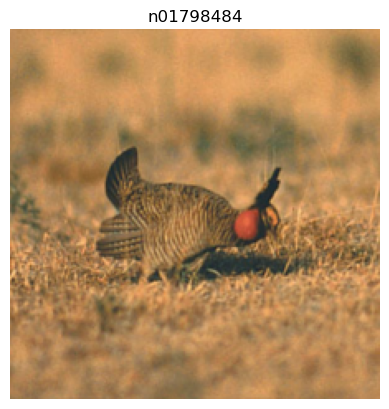

In [13]:
img , label = train_data[id]
plt.imshow(img.permute(1,2,0))
plt.title(class_names[label])
plt.axis(False)

If we had more compute power and I was running then on larger images you could start to slighlty see resemblences to the images.

Showing random convolutional feature maps from indexes: [21, 7, 1, 42, 38]


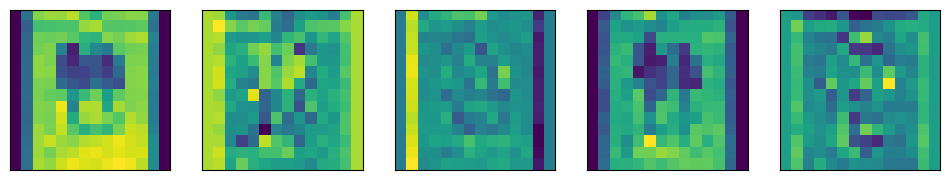

In [14]:
# Plot random 5 convolutional feature maps
import random
random_indexes = random.sample(range(0, 48), k=5) # pick 5 numbers between 0 and the embedding size
print(f"Showing random convolutional feature maps from indexes: {random_indexes}")

# Create plot
fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(12, 12))

# Plot random image feature maps
for i, idx in enumerate(random_indexes):
    image_conv_feature_map = img_out_of_conv[:, idx, :, :] # index on the output tensor of the convolutional layer
    axs[i].imshow(image_conv_feature_map.squeeze().detach().numpy())
    axs[i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[]);

Now we will make a class that does the patch embedding for us.

In [15]:
class PatchEmbedding(nn.Module):
    def __init__(self,
                in_channels = COLOUR_CHANNELS,
                patch_size = PATCH_SIZE,
                embedding_dimension = PATCH_SIZE**2 * COLOUR_CHANNELS
):
        super().__init__()
        self.patcher = nn.Conv2d(
                                in_channels= in_channels,
                                out_channels= embedding_dimension,
                                kernel_size=patch_size,
                                padding=0,
                                stride=patch_size
        )
        self.flatten = nn.Flatten(
            start_dim=2,
            end_dim=3
        )

        self.patch_size=patch_size

    def forward(self,x:torch.Tensor) -> torch.Tensor:
        assert x.shape[-1] % self.patch_size == 0

        patched_x = self.patcher(x)
        flattened_x = self.flatten(patched_x)
        return flattened_x.permute(0,2,1)
    

patchify = PatchEmbedding()

print(f"Input image shape: {img.unsqueeze(0).shape}")
patch_embedded_image = patchify(img.unsqueeze(0)) # add an extra batch dimension on the 0th index, otherwise will error
print(f"Output patch embedding shape: {patch_embedded_image.shape}")


Input image shape: torch.Size([1, 3, 224, 224])
Output patch embedding shape: torch.Size([1, 196, 768])


In [16]:
summary(
    model=PatchEmbedding(),
    input_size=test_image.unsqueeze(0).shape,
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=20,
    row_settings=["var_names"]
)

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
PatchEmbedding (PatchEmbedding)          [1, 3, 224, 224]     [1, 196, 768]        --                   True
├─Conv2d (patcher)                       [1, 3, 224, 224]     [1, 768, 14, 14]     590,592              True
├─Flatten (flatten)                      [1, 768, 14, 14]     [1, 768, 196]        --                   --
Total params: 590,592
Trainable params: 590,592
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 115.76
Input size (MB): 0.60
Forward/backward pass size (MB): 1.20
Params size (MB): 2.36
Estimated Total Size (MB): 4.17

In [17]:
print(f"PATCH_SIZE: {PATCH_SIZE}")
print(f"HEIGHT: {HEIGHT}")
print(f"WIDTH: {WIDTH}")
print(f"IMAGE SHAPE: {test_image.shape}")

PATCH_SIZE: 16
HEIGHT: 224
WIDTH: 224
IMAGE SHAPE: torch.Size([3, 224, 224])


The following code will be a formalisation of recreating the first equation in the paper.
$$
\mathbf{z}_0=\left[\mathbf{x}_{\text {class }} ; \mathbf{x}_p^1 \mathbf{E} ; \mathbf{x}_p^2 \mathbf{E} ; \cdots ; \mathbf{x}_p^N \mathbf{E}\right]+\mathbf{E}_{\text {pos }}, \quad \mathbf{E} \in \mathbb{R}^{\left(P^2 \cdot C\right) \times D}, \mathbf{E}_{\text {pos }} \in \mathbb{R}^{(N+1) \times D}
$$

This section formalises and completes the following math equation sections from Equation 1.

$[\mathbf{x}_p^1 \mathbf{E} ; \mathbf{x}_p^2 \mathbf{E} ; \cdots ; \mathbf{x}_p^N \mathbf{E}] ;  \quad \mathbf{E} \in \mathbb{R}^{\left(P^2 \cdot C\right) \times D}$

In [18]:
print(f"Image tensor shape : {test_image.shape}")

test_image_with_batch_dim = test_image.unsqueeze(0)
print(f"Image tensor shape with batch dimension: {test_image_with_batch_dim.shape}")
batch_size = test_image_with_batch_dim.shape[0]

patch_embedding_layer = PatchEmbedding(
    in_channels=3, #RGB channels
    patch_size=PATCH_SIZE,
    embedding_dimension=PATCH_SIZE**2 * COLOUR_CHANNELS #As stated in the paper D = P^2 * C
)
patch_embedding = patch_embedding_layer(test_image_with_batch_dim)

f"Patch embedding shape: {patch_embedding.shape}"

Image tensor shape : torch.Size([3, 224, 224])
Image tensor shape with batch dimension: torch.Size([1, 3, 224, 224])


'Patch embedding shape: torch.Size([1, 196, 768])'

This creates the class token by creating a trainable tensor of 1s to attach to the patch embedding.
$\mathbf{x}_{\text {class }}$

In [19]:
batch_size = patch_embedding.shape[0]
embedding_dimension = patch_embedding.shape[2]
number_of_patches = patch_embedding.shape[1]
print(f"Batch size: {batch_size}\
        \nEmbedding dimension: {embedding_dimension}\
        \nNumber of patches: {number_of_patches}")

Batch size: 1        
Embedding dimension: 768        
Number of patches: 196


In [20]:
class_token = nn.Parameter(
    torch.ones(batch_size,1,embedding_dimension),
    requires_grad=True #Trainable parameter
)
print(f"Class token shape: {class_token.shape}")

patch_embedding_concat_class_token = torch.cat((class_token,patch_embedding), dim=1)
print(f"Patch embedding with class token shape: {patch_embedding_concat_class_token.shape}")

Class token shape: torch.Size([1, 1, 768])
Patch embedding with class token shape: torch.Size([1, 197, 768])


This creates the position embedding through also creating a tensor of trainable 1s.
$\mathbf{E}_{\text {pos}},  \mathbf{E}_{\text {pos }} \in \mathbb{R}^{(N+1) \times D}$

In [21]:
position_embedding = nn.Parameter(
    torch.ones(1,
               int(number_of_patches+1),
               embedding_dimension)
    ,requires_grad=True #Trainable parameter
)

patch_and_position_embedding = patch_embedding_concat_class_token + position_embedding
print(f"Position embedding shape: {position_embedding.shape}")
print(f"Patch embedding with position embedding shape: {patch_and_position_embedding.shape}")


Position embedding shape: torch.Size([1, 197, 768])
Patch embedding with position embedding shape: torch.Size([1, 197, 768])


Now we will manually create the MultiHeadAttention block, partially custom.
Due to the huge increase in speed, we will use Pytorch's Multihead attention.
The number of heads is decided by ensuring that there are 32 dims that each head is processing.
This section fulfills equation 2 of the ViT people, where layer normalisation is used on the data before MSA to ensure regularised gradients.
Attention is more clearly defined within Google's research paper: Attention is all you need 
$$
\mathbf{z}_{\ell}^{\prime}=\operatorname{MSA}\left(\operatorname{LN}\left(\mathbf{z}_{\ell-1}\right)\right)+\mathbf{z}_{\ell-1}, \quad \ell=1 \ldots L
$$

In [22]:
class MultiHeadAttentionBlock(nn.Module):
    def __init__(self,
                 embedding_dimension:int= PATCH_SIZE**2 * COLOUR_CHANNELS,
                 num_heads=12,
                 attn_dropout=0):
        super().__init__()

        self.layer_norm = nn.LayerNorm(
            normalized_shape= embedding_dimension,
        )

        self.attention_block = nn.MultiheadAttention(
            embed_dim=embedding_dimension,
            num_heads=num_heads,
            dropout=attn_dropout,
        )

    def forward(self,x):
        x = self.layer_norm(x)
        attn_output, _ = self.attention_block(
            query=x,
            key=x,
            value=x,
            need_weights=False
        ) #Ignoring attention weights
        attn_output = attn_output.contiguous() #Making sure the output is contiguous in memory
        return attn_output

This is a MLP, where the input and output size are the embedding dimension as stated by the equation and ensures that the classes can be stacked according to the paper. 
$$
\mathbf{z}_{\ell}=\operatorname{MLP}\left(\operatorname{LN}\left(\mathbf{z}_{\ell}^{\prime}\right)\right)+\mathbf{z}_{\ell}^{\prime}, \quad \ell=1 \ldots L
$$

In [23]:
class MLPBlock(nn.Module):
    def __init__(self,
                 embedding_dim:int=PATCH_SIZE**2 * COLOUR_CHANNELS, 
                 mlp_size=3072,
                 dropout:float=0.1):
        super().__init__()

        self.layer_norm = nn.LayerNorm(normalized_shape=embedding_dim)

        self.mlp = nn.Sequential(
            nn.Linear(in_features=embedding_dim, 
                      out_features=mlp_size),
            nn.GELU(),
            nn.Dropout(p=dropout),
            nn.Linear(in_features=mlp_size, 
                      out_features=embedding_dim),
            nn.Dropout(p=dropout)
        ) #Creating the MLP block


    def forward(self, x):
        x = self.layer_norm(x)
        x = self.mlp(x)
        return x

In [24]:
# Transformer Encoder Block
class TransformerEncoder(nn.Module):
    def __init__(self, 
                embedding_dimension = PATCH_SIZE**2 * COLOUR_CHANNELS,
                attn_dropout = 0.0,
                num_heads = 12,
                mlp_dropout = 0.1, 
                mlp_size:int=3072,
                ):
        super().__init__()

        self.msa = MultiHeadAttentionBlock(
            embedding_dimension=embedding_dimension,
            num_heads=num_heads,
            attn_dropout=attn_dropout
        )
        self.mlp = MLPBlock(
            embedding_dim=embedding_dimension,
            mlp_size=mlp_size,
            dropout=mlp_dropout
        )
    
    def forward(self, x):

        x =  self.msa(x) + x
        x = self.mlp(x) + x
        x = x.contiguous()  

        return x

In [25]:

# Create an instance of TransformerEncoderBlock
transformer_encoder_block = TransformerEncoder(
    embedding_dimension=PATCH_SIZE**2 * COLOUR_CHANNELS, 
    attn_dropout=0.0,
    num_heads=12,
    mlp_dropout=0.1,
    mlp_size=3072
)

# # Print an input and output summary of our Transformer Encoder (uncomment for full output)
summary(model=transformer_encoder_block,
         input_size=(1, 197, 768), # (batch_size, num_patches, embedding_dimension)
         col_names=["input_size", "output_size", "num_params", "trainable"],
         col_width=20,
         row_settings=["var_names"])

Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
TransformerEncoder (TransformerEncoder)            [1, 197, 768]        [1, 197, 768]        --                   True
├─MultiHeadAttentionBlock (msa)                    [1, 197, 768]        [1, 197, 768]        --                   True
│    └─LayerNorm (layer_norm)                      [1, 197, 768]        [1, 197, 768]        1,536                True
│    └─MultiheadAttention (attention_block)        --                   [1, 197, 768]        2,362,368            True
├─MLPBlock (mlp)                                   [1, 197, 768]        [1, 197, 768]        --                   True
│    └─LayerNorm (layer_norm)                      [1, 197, 768]        [1, 197, 768]        1,536                True
│    └─Sequential (mlp)                            [1, 197, 768]        [1, 197, 768]        --                   True
│    │    └─Linear (0)                     

In [26]:
# Create the same as above with torch.nn.TransformerEncoderLayer()
torch_transformer_encoder_layer = nn.TransformerEncoderLayer(d_model=PATCH_SIZE**2 * COLOUR_CHANNELS, # Hidden size D from Table 1 for ViT-Base
                                                             nhead=12, # Heads from Table 1 for ViT-Base
                                                             dim_feedforward=3072, # MLP size from Table 1 for ViT-Base
                                                             dropout=0.1, # Amount of dropout for dense layers from Table 3 for ViT-Base
                                                             activation="gelu", # GELU non-linear activation
                                                             batch_first=True, # Do our batches come first?
                                                             norm_first=True) # Normalize first or after MSA/MLP layers?


summary(model=torch_transformer_encoder_layer,
         input_size=(1, number_of_patches+1, PATCH_SIZE**2 * COLOUR_CHANNELS), # (batch_size, num_patches, embedding_dimension)
         col_names=["input_size", "output_size", "num_params", "trainable"],
         col_width=20,
         row_settings=["var_names"])

Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
TransformerEncoderLayer (TransformerEncoderLayer)  [1, 197, 768]        [1, 197, 768]        --                   True
├─LayerNorm (norm1)                                [1, 197, 768]        [1, 197, 768]        1,536                True
├─MultiheadAttention (self_attn)                   [1, 197, 768]        [1, 197, 768]        2,362,368            True
├─Dropout (dropout1)                               [1, 197, 768]        [1, 197, 768]        --                   --
├─LayerNorm (norm2)                                [1, 197, 768]        [1, 197, 768]        1,536                True
├─Linear (linear1)                                 [1, 197, 768]        [1, 197, 3072]       2,362,368            True
├─Dropout (dropout)                                [1, 197, 3072]       [1, 197, 3072]       --                   --
├─Linear (linear2)                             

In [27]:
embedding_dimension = PATCH_SIZE**2 * COLOUR_CHANNELS

In [28]:
class ViT(nn.Module):
    def __init__(self,
                 img_size:int=HEIGHT, # Input image size
                 in_channels:int=COLOUR_CHANNELS, # Number of channels in input image (colour channels)
                 patch_size:int=PATCH_SIZE, # Patch size
                 num_transformer_layers:int=12, # Layers from Table 1 for ViT-Base
                 embedding_dim:int=embedding_dimension, # Hidden size D from Table 1 for ViT-Base
                 mlp_size:int=3072, # MLP size from Table 1 for ViT-Base
                 num_heads:int=12, # Heads from Table 1 for ViT-Base
                 attn_dropout:float=0, # Dropout for attention projection
                 mlp_dropout:float=0.1, # Dropout for dense/MLP layers
                 embedding_dropout:float=0.1, # Dropout for patch and position embeddings
                 num_classes:int=len(class_names)): # 100 classes for the 10% subset of imagenet used
        super().__init__()
        # Define the ViT architecture here
        
        assert img_size % patch_size == 0, f"Image size must be divisible by patch size, image size: {img_size}, patch size: {patch_size}."

        # 4. Calculate number of patches (height * width/patch^2)
        self.num_patches = (img_size * img_size) // patch_size**2

        self.class_embedding = nn.Parameter(data=torch.randn(1, 1, embedding_dim),
                                            requires_grad=True)

        self.position_embedding = nn.Parameter(data=torch.randn(1, self.num_patches+1, embedding_dim),
                                               requires_grad=True)

        self.embedding_dropout = nn.Dropout(p=embedding_dropout)

        self.patch_embedding = PatchEmbedding(in_channels=in_channels,
                                              patch_size=patch_size,
                                              )

        self.transformer_encoder = nn.Sequential(*[nn.TransformerEncoderLayer(d_model=PATCH_SIZE**2 * COLOUR_CHANNELS, # Hidden size D from Table 1 for ViT-Base
                                                             nhead=12, # Heads from Table 1 for ViT-Base
                                                             dim_feedforward=3072, # MLP size from Table 1 for ViT-Base
                                                             dropout=0.1, # Amount of dropout for dense layers from Table 3 for ViT-Base
                                                             activation="gelu", # GELU non-linear activation
                                                             batch_first=True, # Do our batches come first?
                                                             norm_first=True)
                                                             ]) # Normalize first or after MSA/MLP layers? for _ in range(num_transformer_layers)])

        self.classifier = nn.Sequential(
            nn.LayerNorm(normalized_shape=embedding_dim),
            nn.Linear(in_features=embedding_dim,
                      out_features=num_classes)
        )
    
    def forward(self, x:torch.Tensor) -> torch.Tensor:

        batch_size = x.shape[0]

        # safer: create a true batched class token (no overlapping memory)
        # option A: repeat (makes new memory)
        class_token = self.class_embedding.repeat(batch_size, 1, 1)   # (B, 1, D)

        # option B: expand then clone to get contiguous non-overlapping memory
        # class_token = self.class_embedding.expand(batch_size, -1, -1).clone()

        # patch embedding
        x = self.patch_embedding(x)           # expect (B, num_patches, D)
        x = x.contiguous()                    # ensure contiguous after any permute/unfold inside PatchEmbedding

        # concat
        x = torch.cat((class_token, x), dim=1)

        # add positional embedding (positional param is (1, N+1, D) — broadcast is fine)
        x = self.position_embedding + x

        x = self.embedding_dropout(x)

        x = self.transformer_encoder(x)

        x = self.classifier(x[:, 0].contiguous())   # ensure CLS token is contiguous before Linear
        return x


In [29]:
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print(f"Using device: {device}")

Using device: mps


In [30]:
num_workers = 0
BATCH_SIZE = 512

train_dataloader = DataLoader(
  train_data,
  batch_size=BATCH_SIZE,
  shuffle=True,
  num_workers=num_workers,
  pin_memory=True,
  )

test_dataloader = DataLoader(
  test_data,
  batch_size=BATCH_SIZE,
  shuffle=False,
  num_workers=num_workers,
  pin_memory=True,
)

In [31]:
vit = ViT(
    img_size=HEIGHT, # Input image size
    in_channels=COLOUR_CHANNELS, # Number of channels in input image (colour channels)
    patch_size=PATCH_SIZE, # Patch size
    num_transformer_layers=12, # Layers from Table 1 for ViT-Base
    embedding_dim=embedding_dimension, # Hidden size D from Table 1 for ViT-Base
    mlp_size=3072, # MLP size from Table 1 for ViT-Base
    num_heads=6, # Heads from Table 1 for ViT-Base
    attn_dropout=0, # Dropout for attention projection
    mlp_dropout=0.1, # Dropout for dense/MLP layers
    embedding_dropout=0.1, # Dropout for patch and position embeddings
    num_classes=len(class_names) # Default for ImageNet but can customize this
)


In [32]:
"""
summary(
    model=vit,
    input_size=(BATCH_SIZE,COLOUR_CHANNELS,HEIGHT,WIDTH),
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=20,
    row_settings=["var_names"]
)"""

'\nsummary(\n    model=vit,\n    input_size=(BATCH_SIZE,COLOUR_CHANNELS,HEIGHT,WIDTH),\n    col_names=["input_size", "output_size", "num_params", "trainable"],\n    col_width=20,\n    row_settings=["var_names"]\n)'

In [33]:
torch.mps.empty_cache()

In [34]:
# Setup the optimizer to optimize our ViT model parameters using hyperparameters from the ViT paper
optimizer = torch.optim.AdamW(params=vit.parameters(),
                             lr=3e-3, # Base LR from Table 3 for ViT-* ImageNet-1k
                             betas=(0.9, 0.999), # default values but also mentioned in ViT paper section 4.1 (Training & Fine-tuning)
                             weight_decay=0.3) # from the ViT paper section 4.1 (Training & Fine-tuning) and Table 3 for ViT-* ImageNet-1k

# Setup the loss function for multi-class classification
loss_fn = torch.nn.CrossEntropyLoss()

vit.to(device)      # Move the model to the target device


ViT(
  (embedding_dropout): Dropout(p=0.1, inplace=False)
  (patch_embedding): PatchEmbedding(
    (patcher): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (flatten): Flatten(start_dim=2, end_dim=3)
  )
  (transformer_encoder): Sequential(
    (0): TransformerEncoderLayer(
      (self_attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
      )
      (linear1): Linear(in_features=768, out_features=3072, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (linear2): Linear(in_features=3072, out_features=768, bias=True)
      (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout1): Dropout(p=0.1, inplace=False)
      (dropout2): Dropout(p=0.1, inplace=False)
    )
  )
  (classifier): Sequential(
    (0): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=768, out_features

In [36]:
EPOCHES = 1 # Number of epochs to train for

lambalr_scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer=optimizer,
    lr_lambda= lambda step: lr_lambda(step, warmup_steps=1000, total_steps=(EPOCHES * len(train_dataloader)))
)

results = train(model=vit,
                       train_dataloader=train_dataloader,
                       test_dataloader=test_dataloader,
                       optimizer=optimizer,
                       scheduler=lambalr_scheduler,
                       loss_fn=loss_fn,
                       epochs=EPOCHES,
                       device=device)

Epoch 0/1:   0%|          | 0/254 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 4.1232 | train_acc: 0.0779 | test_loss: 3.6864 | test_acc: 0.1403


I only ran it for 2 epoches cause it takes 16 minutes per epoch for me. 


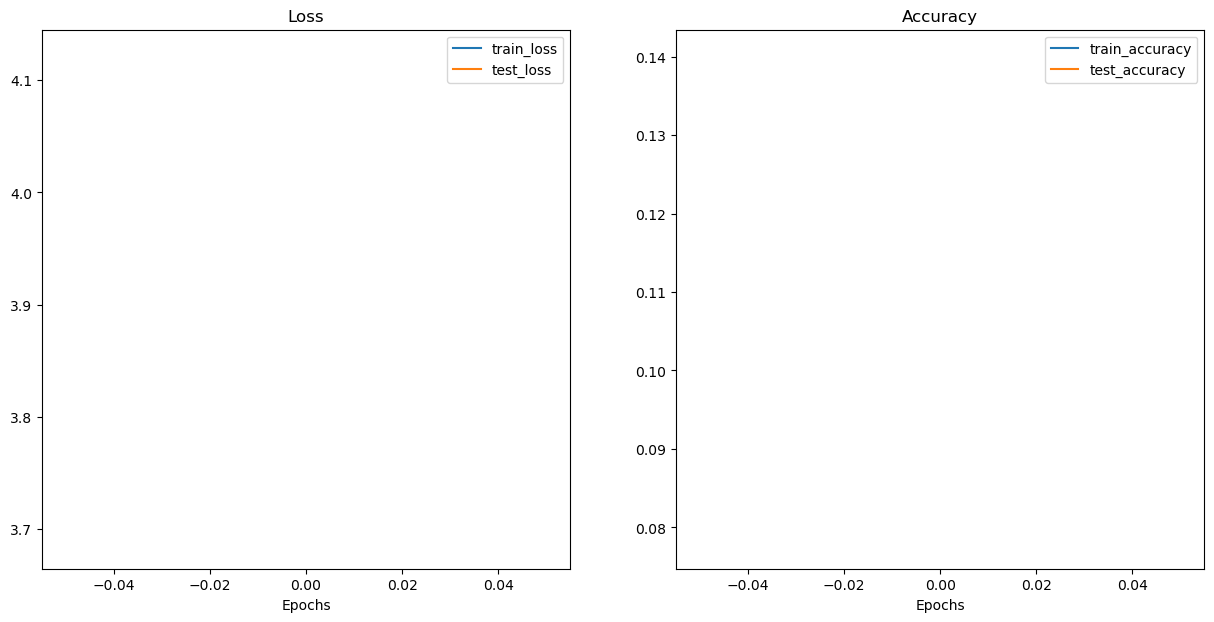

In [38]:
loss = results["train_loss"]
test_loss = results["test_loss"]

accuracy = results["train_acc"]
test_accuracy = results["test_acc"]

epochs = range(len(results["train_loss"]))

plt.figure(figsize=(15, 7))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(epochs, loss, label="train_loss")
plt.plot(epochs, test_loss, label="test_loss")
plt.title("Loss")
plt.xlabel("Epochs")
plt.legend()

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, accuracy, label="train_accuracy")
plt.plot(epochs, test_accuracy, label="test_accuracy")
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.legend()